In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Fake.csv to Fake.csv
Saving True.csv to True.csv


In [ ]:
!ls

Fake.csv  sample_data  True.csv


In [ ]:
import os

print(os.listdir())

['.config', 'Fake.csv', 'True.csv', 'sample_data']


In [ ]:
import pandas as pd

fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

In [ ]:
print(fake.head())
print(true.head())

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept t

In [ ]:
fake["label"] = 0
true["label"] = 1

In [ ]:
print(fake.head())
print(true.head())

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  label  
0  December 31, 2017      0  
1  December 31, 2017      0  
2  December 30, 2017      0  
3  December 29, 2017      0  
4  December 25, 2017      0  
                                               title  \
0  As U.S. budget fight looms, Republicans

In [ ]:
data = pd.concat([fake, true])

data = data.sample(frac=1, random_state=42)

data.reset_index(drop=True, inplace=True)

print(data.head())

                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...  politicsNews   
3  On Monday, Donald Trump once again embarrassed...          News   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...  politicsNews   

                  date  label  
0    February 13, 2017      0  
1       April 5, 2017       1  
2  September 27, 2017       1  
3         May 22, 2017      0  
4       June 24, 2016       1  


In [ ]:
import re

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z]", " ", text)

    return text

In [ ]:
data["text"] = data["text"].apply(clean_text)

In [ ]:
data.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [ ]:
data.dropna(inplace=True)

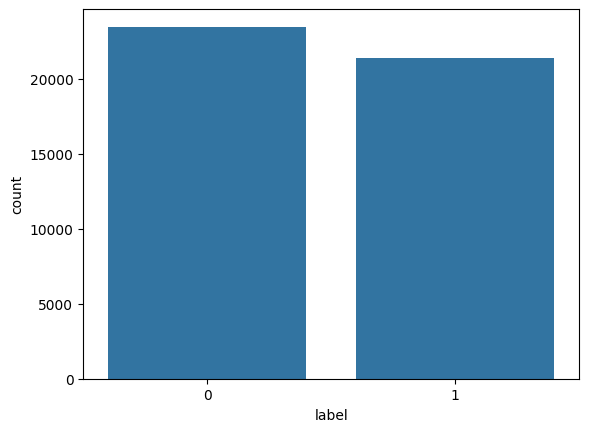

In [ ]:
sns.countplot(x="label", data=data)
plt.show()

In [ ]:
from wordcloud import WordCloud

In [ ]:
fake_words = " ".join(data[data.label==0]["text"])

In [ ]:
X = data["text"]

y = data["label"]

In [ ]:
tfidf = TfidfVectorizer(
max_features=5000,
stop_words='english'
)

In [ ]:
X = tfidf.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train,y_train)

pred1 = lr.predict(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train,y_train)

pred2 = rf.predict(X_test)

In [ ]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train,y_train)

pred3 = svm.predict(X_test)

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier()

mlp.fit(X_train,y_train)

pred4 = mlp.predict(X_test)

In [ ]:
accuracy_score(y_test,pred1)

0.983630289532294

In [ ]:
classification_report(y_test,pred1)

'              precision    recall  f1-score   support\n\n           0       0.99      0.98      0.98      4710\n           1       0.98      0.99      0.98      4270\n\n    accuracy                           0.98      8980\n   macro avg       0.98      0.98      0.98      8980\nweighted avg       0.98      0.98      0.98      8980\n'

In [ ]:
confusion_matrix(y_test,pred1)

array([[4619,   91],
       [  56, 4214]])

In [ ]:
tfidf.get_feature_names_out()

array(['abadi', 'abandon', 'abandoned', ..., 'zones', 'zor', 'zuma'],
      dtype=object)

In [ ]:
from sklearn.metrics import roc_curve

In [ ]:
from sklearn.metrics import accuracy_score

lr_acc = accuracy_score(y_test, pred1)
rf_acc = accuracy_score(y_test, pred2)
svm_acc = accuracy_score(y_test, pred3)
mlp_acc = accuracy_score(y_test, pred4)

In [ ]:
models = ["Logistic Regression", "Random Forest", "SVM", "Neural Network"]

accuracies = [lr_acc, rf_acc, svm_acc, mlp_acc]

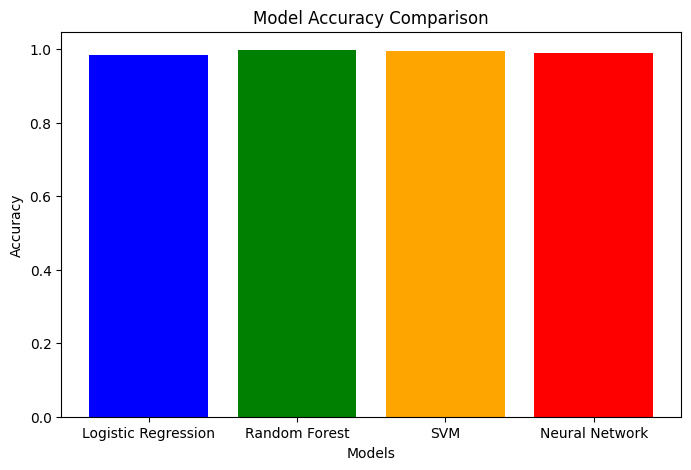

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(models, accuracies, color=["blue","green","orange","red"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

In [ ]:
def predict_news(news):

    news = clean_text(news)

    vector = tfidf.transform([news])

    pred = svm.predict(vector)

    if pred[0] == 1:
        return "Real News"
    else:
        return "Fake News"

In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np

print("Label counts:")
print(data["label"].value_counts())

print("\nPrediction counts:")
print(np.unique(pred3, return_counts=True))

print("\nSVM Accuracy:")
print(accuracy_score(y_test, pred3))

Label counts:
label
0    23481
1    21417
Name: count, dtype: int64

Prediction counts:
(array([0, 1]), array([4706, 4274]))

SVM Accuracy:
0.9933184855233853


In [ ]:
print("REAL:", predict_news(true.iloc[0]["text"]))
print("FAKE:", predict_news(fake.iloc[0]["text"]))

REAL: Real News
FAKE: Fake News


In [ ]:
sample = true.iloc[10]["text"]
predict_news(sample)

'Real News'

In [ ]:
sample = fake.iloc[10]["text"]
predict_news(sample)

'Fake News'

In [ ]:
predict_news("Government announces new education policy")

'Fake News'

In [ ]:
sample_news = true.iloc[0]["text"]

predict_news(sample_news)

'Real News'

In [ ]:
predict_news("WASHINGTON (Reuters) - A lawyer nominated by President Donald Trump to serve as a federal judge withdrew from consideration on Monday after video of his Senate confirmation hearing showing him unable to provide answers to rudimentary legal questions went viral last week. Trump accepted Matthew Petersenâ€™s offer to withdraw his nomination as a district court judge in Washington, a White House official said. Petersen, a Republican member of the Federal Election Commission, became the latest of Trumpâ€™s judicial nominations to fail as the president seeks to win confirmation of judges who will make the federal judiciary more conservative. â€œJust because youâ€™ve seen â€˜My Cousin Vinnyâ€™ doesnâ€™t qualify you to be a federal judge,â€ Republican Senator John Kennedy, who grilled Petersen during his Dec. 13 confirmation hearing, told WWL-TV, referring to the 1992 comedy film about a novice lawyer. Kennedy, who has been critical of some of Trumpâ€™s judicial nominees, asked several basic legal questions that Petersen could not answer. The video was shown on cable news shows and widely viewed on the internet. â€œWhile I am honored to have been nominated for this position, it has become clear to me over the past few days that my nomination has become a distraction - and that is not fair to you or your administration,â€ Petersen wrote in his withdrawal letter to Trump. â€œI had hoped that my nearly two decades of public service might carry more weight than my two worst minutes on television,â€ Petersen added. Petersen became the third Trump judicial pick whose nomination foundered in the past week. Republican Senator Chuck Grassley, chairman of the Senate Judiciary Committee, said last week Trumpâ€™s nominations of Jeff Mateer and Brett Talley would not move forward. Both had faced criticism for controversial statements. Talley was reported by online magazine Slate as having posted online sympathetic comments about the early history of the Ku Klux Klan (KKK) white supremacist group. He also failed to disclose that his wife works in the White House counselâ€™s office, which overseas judicial nominations. Mateer ran into trouble over 2015 speeches including one in which he referred to transgender children as being part of â€œSatanâ€™s plans,â€ CNN reported. Despite those setbacks, Trump has made significant progress in filling vacancies on the federal courts with conservative judges, including 12 on the important courts of appeal. He also appointed Justice Neil Gorsuch to fill a vacancy on the Supreme Courts, restoring the high courtâ€™s conservative majority. ")

'Real News'